In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

\begin{equation}
\Gamma = \frac{Z_L - Z_c }{Z_L + Z_c},
\end{equation}
where $Z_L$ and $Z_c$ are load input impedance and cable impedance, respectively.

In [ ]:
# describes reflection from a cable of impedence z_c with load z_l

def fit_function(z_l, *popt): # the asterisk collects all the passed parameters into a tuple
    z_c = popt[0]
    return (z_l - z_c)/(z_l+z_c)


In [65]:
df_cable_1 = pd.read_csv("smyrichinsky_cable_1.txt")

# columns: resistance, incident_wave_ampl,incident_wave_error,reflected_wave_ampl,reflected_wave_error

print(list(df_cable_1))

resistance_1 = df_cable_1["resistance"].to_numpy()
incident_ampl_1 = df_cable_1["incident_wave_ampl"].to_numpy()
incident_error_1 = df_cable_1["incident_wave_error"].to_numpy()
reflected_ampl_1 = df_cable_1["reflected_wave_ampl"].to_numpy()
reflected_error_1 = df_cable_1["reflected_wave_error"].to_numpy()

gamma_1 = reflected_ampl_1/incident_ampl_1
gamma_error_1 = np.abs(gamma_1)*np.sqrt( (reflected_error_1/reflected_ampl_1)**2 + (incident_error_1/incident_ampl_1)**2  )
for i in range(len(resistance_1)):
    print("resistance: ", resistance_1[i], "peak height 2: ", reflected_ampl_1[i], "gamma: ", gamma_1[i], "gamma error: ", gamma_error_1[i], "\n")

['resistance', 'incident_wave_ampl', 'incident_wave_error', 'reflected_wave_ampl', 'reflected_wave_error']
resistance:  0.0 peak height 2:  -93.24 gamma:  -0.9141176470588235 gamma error:  0.026565632366196395 

resistance:  10.0 peak height 2:  -66.12 gamma:  -0.6482352941176471 gamma error:  0.02336716114813586 

resistance:  20.0 peak height 2:  -47.0 gamma:  -0.46078431372549017 gamma error:  0.021589314355460593 

resistance:  30.0 peak height 2:  -31.16 gamma:  -0.30549019607843136 gamma error:  0.02050238177759884 

resistance:  40.0 peak height 2:  -19.76 gamma:  -0.19372549019607846 gamma error:  0.019972391224084455 

resistance:  10000.0 peak height 2:  84.0 gamma:  0.8235294117647058 gamma error:  0.021840538198960896 

resistance:  5000.0 peak height 2:  84.5 gamma:  0.8284313725490197 gamma error:  0.017830458100454666 

resistance:  4000.0 peak height 2:  83.6 gamma:  0.8196078431372549 gamma error:  0.020511125595064503 

resistance:  3000.0 peak height 2:  83.6 gamma: 

In [59]:
guess = [50]

best_fit, covariance = curve_fit(fit_function, resistance_1, gamma_1, sigma = gamma_error_1, 
                                 p0 = guess, absolute_sigma = True)

perr = np.sqrt(np.diag(covariance))
fit = fit_function(resistance, *best_fit)
chi_squared = np.sum(((gamma_1 - fit)/gamma_error_1)**2)
ndof = len(gamma_1) - len(guess)

print("best fit = %f +- %f ohms"%(best_fit[0],perr[0]))
print('chisq = %f / %d'%(chi_squared,ndof))

best fit = 60.814857 +- 1.167440 ohms
chisq = 186.028494 / 13


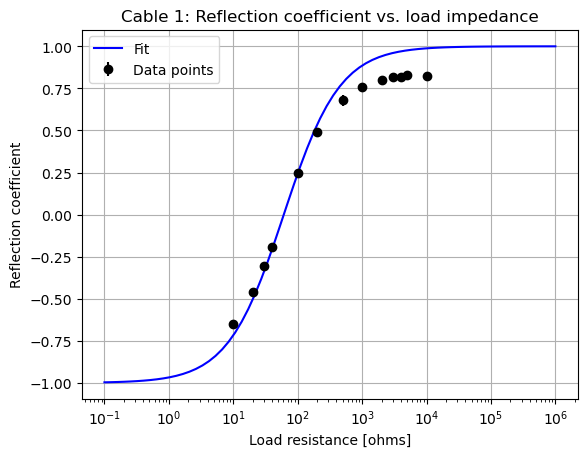

In [60]:
fig, ax = plt.subplots()
ax.errorbar(resistance_2, gamma_2, yerr = gamma_error_2, fmt = 'o', color = "black", label = "Data points")
rl_smooth       = 10**(np.linspace(-1,6,70))
best_fit_smooth = fit_function(rl_smooth,*best_fit)
ax.plot(rl_smooth, best_fit_smooth, color = "blue", label = "Fit")
ax.set_xscale("log")
ax.grid()
ax.set_xlabel("Load resistance [ohms]")
ax.set_ylabel("Reflection coefficient")
ax.set_title("Cable 1: Reflection coefficient vs. load impedance")
ax.legend()

## Cable 2

In [66]:
df_cable_2 = pd.read_csv("smyrichinsky_cable_2.txt")

# columns: resistance, incident_wave_ampl,incident_wave_error,reflected_wave_ampl,reflected_wave_error

print(list(df_cable_2))

resistance_2 = df_cable_2["resistance"].to_numpy()
incident_ampl_2 = df_cable_2["incident_wave_ampl"].to_numpy()
incident_error_2 = df_cable_2["incident_wave_error"].to_numpy()
reflected_ampl_2 = df_cable_2["reflected_wave_ampl"].to_numpy()
reflected_error_2 = df_cable_2["reflected_wave_error"].to_numpy()

gamma_2 = reflected_ampl_2/incident_ampl_2
gamma_error_2 = np.abs(gamma_2)*np.sqrt( (reflected_error_2/reflected_ampl_2)**2 + (incident_error_2/incident_ampl_2)**2  )
print(gamma_2)

for i in range(len(resistance_1)):
    print("resistance: ", resistance_2[i], "peak height 2: ", reflected_ampl_2[i], "gamma: ", gamma_2[i], "gamma error: ", gamma_error_2[i], "\n")

['resistance', 'incident_wave_ampl', 'incident_wave_error', 'reflected_wave_ampl', 'reflected_wave_error']
[-0.92156863 -0.65196078 -0.46078431 -0.31372549 -0.21568627  0.85294118
  0.84313725  0.84313725  0.83333333  0.81372549  0.78431373  0.69607843
  0.49019608  0.25980392]
resistance:  0 peak height 2:  -94.0 gamma:  -0.9215686274509803 gamma error:  0.026664422736485508 

resistance:  10 peak height 2:  -66.5 gamma:  -0.6519607843137255 gamma error:  0.023406976094853094 

resistance:  20 peak height 2:  -47.0 gamma:  -0.46078431372549017 gamma error:  0.021589314355460593 

resistance:  30 peak height 2:  -32.0 gamma:  -0.3137254901960784 gamma error:  0.020550139200142665 

resistance:  40 peak height 2:  -22.0 gamma:  -0.21568627450980393 gamma error:  0.020058742730865952 

resistance:  10000 peak height 2:  87.0 gamma:  0.8529411764705882 gamma error:  0.02577151438466474 

resistance:  5000 peak height 2:  86.0 gamma:  0.8431372549019608 gamma error:  0.02564718197640587 



In [53]:
guess = [50]

best_fit, covariance = curve_fit(fit_function, resistance_2, gamma_2, sigma = gamma_error_2, 
                                 p0 = guess, absolute_sigma = True)

perr = np.sqrt(np.diag(covariance))
fit = fit_function(resistance_2, *best_fit)
chi_squared = np.sum(((gamma_2 - fit)/gamma_error_2)**2)
ndof = len(gamma_2) - len(guess)

print("best fit = %f +- %f ohms"%(best_fit[0],perr[0]))
print('chisq = %f / %d'%(chi_squared,ndof))

best fit = 62.242670 +- 1.112218 ohms
chisq = 346.917726 / 13


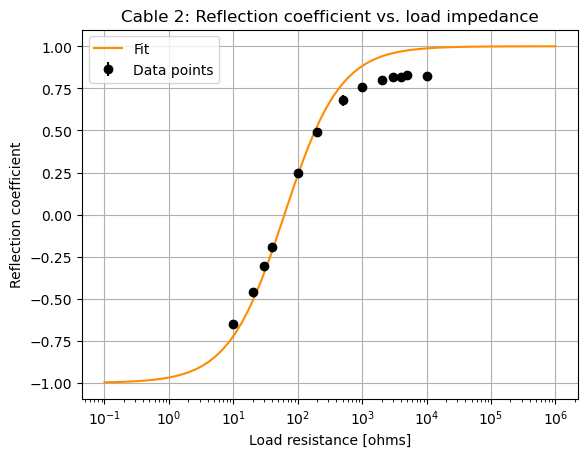

In [54]:
fig, ax = plt.subplots()
ax.errorbar(resistance, gamma, yerr = gamma_error, fmt = 'o', color = "black", label = "Data points")
rl_smooth       = 10**(np.linspace(-1,6,70))
best_fit_smooth = fit_function(rl_smooth,*best_fit)
ax.plot(rl_smooth, best_fit_smooth, color = "darkorange", label = "Fit")
ax.set_xscale("log")
ax.grid()
ax.set_xlabel("Load resistance [ohms]")
ax.set_ylabel("Reflection coefficient")
ax.set_title("Cable 2: Reflection coefficient vs. load impedance")
ax.legend()